<a href="https://colab.research.google.com/github/patriciasandagorda/AST/blob/main/PRACTICA_AST_Clase_6_7A_NBEATS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 6</h3>
    <h3>Ejercicio NBEATS 1 </h3>
        <p>Docentes: Rodrigo Del Rosso, Drago Braian<p>
</div>

# N-BEATS vs N-BEATSx con una variable exógena

Este notebook compara:

- **N-BEATS:** utiliza únicamente el historial de la serie objetivo.
- **N-BEATSx:** incorpora una variable exógena conocida a futuro: `is_weekend`.

Se genera una serie sintética de ventas diarias con tendencia, estacionalidad semanal, ruido y un incremento adicional durante sábados y domingos.

## 1. Instalar dependencias

In [ ]:
# NeuralForecast incluye las implementaciones de N-BEATS y N-BEATSx.
# La instalación puede requerir reiniciar la sesión únicamente si Colab lo solicita.
!pip -q install neuralforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.0/308.0 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 63.6 MB/s eta 0:00:00


## 2. Importar librerías y fijar la semilla

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NBEATSx
from neuralforecast.losses.pytorch import MAE

np.random.seed(7)

## 3. Crear una serie sintética

In [ ]:
n_days = 400
dates = pd.date_range("2024-01-01", periods=n_days, freq="D")
t = np.arange(n_days)

trend = 0.05 * t
weekly_seasonality = 3 * np.sin(2 * np.pi * t / 7)
is_weekend = (dates.dayofweek >= 5).astype(float)
weekend_boost = 8 * is_weekend
noise = np.random.normal(0, 1.0, n_days)

y = 20 + trend + weekly_seasonality + weekend_boost + noise

df = pd.DataFrame({
    "unique_id": "store_1",
    "ds": dates,
    "y": y,
    "is_weekend": is_weekend,
})

df.head()

,unique_id,ds,y,is_weekend
0,store_1,2024-01-01,21.690526,0.0
1,store_1,2024-01-02,21.929557,0.0
2,store_1,2024-01-03,23.057604,0.0
3,store_1,2024-01-04,21.859168,0.0
4,store_1,2024-01-05,18.109426,0.0


### Visualizar la serie completa

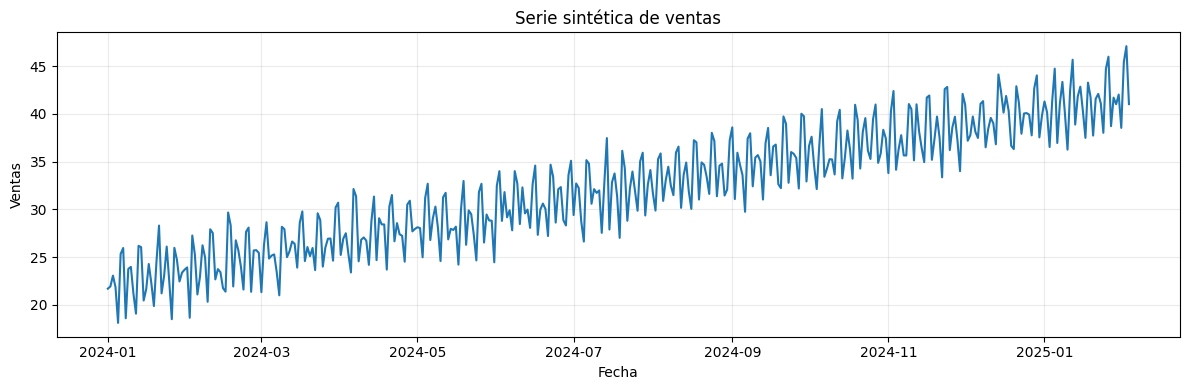

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(df["ds"], df["y"])
plt.title("Serie sintética de ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Separar entrenamiento y prueba

In [ ]:
HORIZON = 14

train_df = df.iloc[:-HORIZON].copy()
test_df = df.iloc[-HORIZON:].copy()

print(f"Observaciones de entrenamiento: {len(train_df)}")
print(f"Observaciones de prueba: {len(test_df)}")

test_df

Observaciones de entrenamiento: 386
Observaciones de prueba: 14


,unique_id,ds,y,is_weekend
386,store_1,2025-01-21,41.575901,0.0
387,store_1,2025-01-22,42.099522,0.0
388,store_1,2025-01-23,41.105211,0.0
389,store_1,2025-01-24,38.021662,0.0
390,store_1,2025-01-25,44.734574,1.0
391,store_1,2025-01-26,45.992304,1.0
392,store_1,2025-01-27,38.714955,0.0
393,store_1,2025-01-28,41.708337,0.0
394,store_1,2025-01-29,41.017571,0.0
395,store_1,2025-01-30,42.024544,0.0


## 5. Definir N-BEATS y N-BEATSx

In [ ]:
horizon = HORIZON
input_size = 28 #ventana de 28 pasos pasados que mira para cada predicción

nbeats = NBEATS(
    h=horizon,
    input_size=input_size,
    max_steps=300,
    loss=MAE(),
    random_seed=7,
)

nbeatsx = NBEATSx(
    h=horizon,
    input_size=input_size,
    max_steps=300,
    loss=MAE(),
    futr_exog_list=["is_weekend"],
    random_seed=7,
)

nf = NeuralForecast(
    models=[nbeats, nbeatsx],
    freq="D",
)

INFO:lightning_fabric.utilities.seed:Seed set to 7
INFO:lightning_fabric.utilities.seed:Seed set to 7


## 6. Entrenar los modelos

In [ ]:
nf.fit(df=train_df)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 2.5 M  | train
--------------------------------------------------------------
2.5 M     Trainable params
1.2 K     Non-trainable params
2.5 M     Total params
9.844     Total estimated model params s

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.


## 7. Generar el pronóstico

In [ ]:
# N-BEATSx necesita conocer los valores futuros de la variable exógena.
futr_df = test_df[["unique_id", "ds", "is_weekend"]].copy()

forecasts = nf.predict(futr_df=futr_df)
forecasts

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

,unique_id,ds,NBEATS,NBEATSx
0,store_1,2025-01-21,40.828701,41.333286
1,store_1,2025-01-22,42.873848,42.900066
2,store_1,2025-01-23,40.692661,40.746807
3,store_1,2025-01-24,37.610634,37.487816
4,store_1,2025-01-25,44.099388,44.152779
5,store_1,2025-01-26,44.586437,44.825562
6,store_1,2025-01-27,38.323177,38.595200
7,store_1,2025-01-28,41.020866,41.647289
8,store_1,2025-01-29,43.411774,43.057430
9,store_1,2025-01-30,40.752197,41.017506


## 8. Evaluar el error MAE

In [ ]:
forecasts = forecasts.merge(
    test_df[["unique_id", "ds", "y"]],
    on=["unique_id", "ds"],
    how="left",
)

mae_nbeats = np.mean(np.abs(forecasts["NBEATS"] - forecasts["y"]))
mae_nbeatsx = np.mean(np.abs(forecasts["NBEATSx"] - forecasts["y"]))

results = pd.DataFrame({
    "Modelo": ["NBEATS", "NBEATSx"],
    "Información utilizada": ["Solo serie objetivo", "Serie objetivo + is_weekend"],
    "MAE": [mae_nbeats, mae_nbeatsx],
}).sort_values("MAE")

results

,Modelo,Información utilizada,MAE
1,NBEATSx,Serie objetivo + is_weekend,0.847882
0,NBEATS,Solo serie objetivo,1.051474


## 9. Graficar la comparación

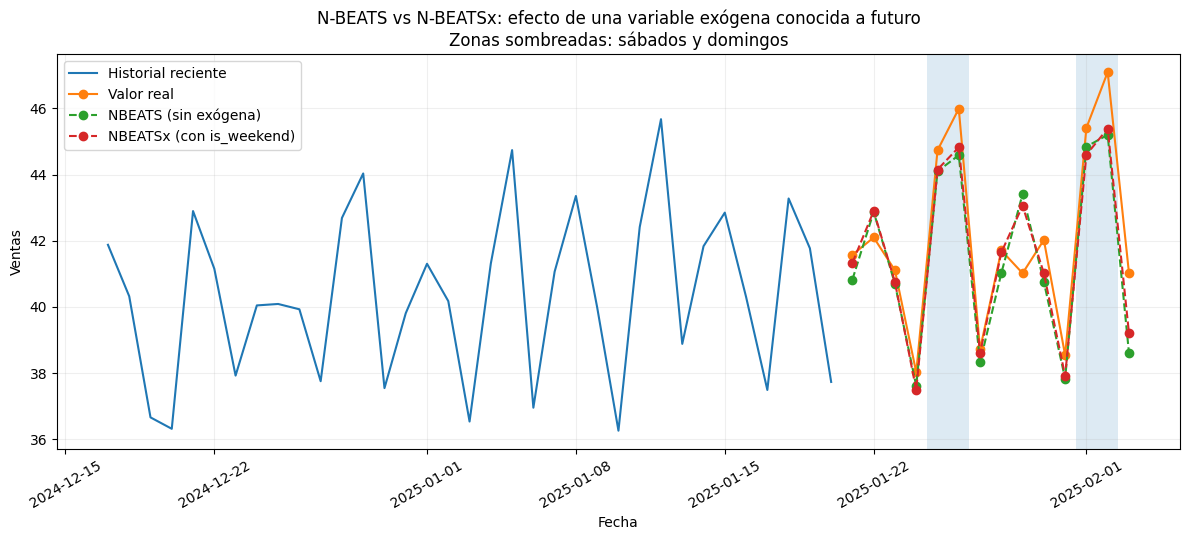

Gráfico guardado en: /content/nbeatsx_comparison.png


In [ ]:
plt.figure(figsize=(12, 5.5))

hist = train_df.tail(35)
plt.plot(hist["ds"], hist["y"], label="Historial reciente")
plt.plot(forecasts["ds"], forecasts["y"], marker="o", label="Valor real")
plt.plot(
    forecasts["ds"], forecasts["NBEATS"],
    marker="o", linestyle="--", label="NBEATS (sin exógena)"
)
plt.plot(
    forecasts["ds"], forecasts["NBEATSx"],
    marker="o", linestyle="--", label="NBEATSx (con is_weekend)"
)

for _, row in test_df.iterrows():
    if row["is_weekend"] == 1:
        plt.axvspan(
            row["ds"] - pd.Timedelta(hours=12),
            row["ds"] + pd.Timedelta(hours=12),
            alpha=0.15,
        )

plt.title(
    "N-BEATS vs N-BEATSx: efecto de una variable exógena conocida a futuro" + "\n" +
    "Zonas sombreadas: sábados y domingos"
)
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(alpha=0.2)
plt.xticks(rotation=30)
plt.tight_layout()

output_path = "/content/nbeatsx_comparison.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Gráfico guardado en: {output_path}")

## Interpretación

N-BEATS intenta inferir el comportamiento futuro utilizando solamente los valores históricos de `y`. En cambio, N-BEATSx recibe explícitamente el calendario futuro mediante `is_weekend`.

Por eso, cuando el salto de ventas de sábados y domingos depende de una información conocida anticipadamente, N-BEATSx debería capturarlo con mayor facilidad y obtener un MAE menor. El resultado exacto puede variar ligeramente por el entrenamiento de la red neuronal.